In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader 
from torchvision.models import resnet34, ResNet34_Weights
from torchvision import transforms as T
import torch.nn.init as init 

from torch import nn
import torch
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.optim as optim
# !pip install -q pytorch-optimizer
import pytorch_optimizer as optim1


from torchmetrics.functional import mean_squared_error, r2_score
from pytorch_lightning import LightningModule
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.loggers import CSVLogger
import pytorch_lightning as pl
from torchmetrics.regression import MeanAbsoluteError, MeanSquaredError, R2Score

In [29]:
import kagglehub

# Download latest version
# path = kagglehub.dataset_download("trolukovich/apparel-images-dataset")

# print("Path to dataset files:", path)

In [ ]:
class MultiLabelImageDataset(Dataset):
    def __init__(self, image_paths, labels=tuple, transform=None, n_classes=None, device="cpu"):
        """
        Dataset Multi-Label untuk image classification.

        Parameters:
        - image_paths: list/array of image file paths
        - labels: list of lists (label indices) atau multi-hot matrix
        - transform: transformasi gambar (torchvision.transforms)
        - n_classes: jumlah kelas (wajib jika labels berupa list of indices)
        - device: 'cpu' atau 'cuda'
        """
        self.image_paths = image_paths
        self.transform = transform
        self.device = device
        
        # Konversi labels ke multi-hot jika perlu
        if isinstance(labels, (list, tuple)) and isinstance(labels[0], (list, tuple)):
            if n_classes is None:
                raise ValueError("n_classes harus diberikan jika labels berupa list of indices")
            multi_hot = np.zeros((len(labels), n_classes), dtype=np.float32)
            for i, lbls in enumerate(labels):
                multi_hot[i, lbls] = 1.0
            self.labels = torch.tensor(multi_hot, dtype=torch.float32)
        elif hasattr(labels, "to_numpy"):  # Pandas DataFrame
            self.labels = torch.tensor(labels.to_numpy(), dtype=torch.float32)
        elif isinstance(labels, np.ndarray):
            self.labels = torch.tensor(labels, dtype=torch.float32)
        elif isinstance(labels, torch.Tensor):
            self.labels = labels.float()
        else:
            raise TypeError("Format labels tidak didukung")

        self.labels = self.labels.to(device)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label
    


class MultiCategoryImageDataset(Dataset):
    def __init__(self, image_paths, color_labels, apparel_labels, transform=None):
        """
        Dataset untuk multi-category classification (multi-output).

        Parameters:
        - image_paths: list of file paths
        - color_labels: list/array of integer label untuk color
        - apparel_labels: list/array of integer label untuk apparel
        - transform: torchvision.transforms (opsional)
        """
        self.image_paths = image_paths
        self.color_labels = torch.tensor(color_labels, dtype=torch.long)
        self.apparel_labels = torch.tensor(apparel_labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)

        color = self.color_labels[idx]
        apparel = self.apparel_labels[idx]

        return img, (color, apparel)



In [31]:
color_list = []
apparel_list = []
img_path = []
failed_img = 0

path = 'ImageFolder'
for label in os.listdir(path):
    for img in os.listdir(path + f'/{label}'):
        img_ok = path + f'/{label}/{img}'
        try: 
            check_img = Image.open(img_ok).convert('RGB')
            check_img.verify()
            img_path.append(img_ok)
            color, apparel = label.split('_')
            color_list.append(color)
            apparel_list.append(apparel)
        except:
            failed_img += 1

print(f'{failed_img} Images Failed Verification')

df = pd.DataFrame({
    'img_path': img_path,
    'color': color_list,
    'apparel': apparel_list
})

print(f'Number of image = {df.shape[0]}')

df.head(3)

0 Images Failed Verification
Number of image = 11385


,img_path,color,apparel
0,ImageFolder/black_dress/0097960878307e559459d9...,black,dress
1,ImageFolder/black_dress/038098f911bf30451c109d...,black,dress
2,ImageFolder/black_dress/0522170fba54aa3e809148...,black,dress


In [37]:
df['labels'] = df['color'] + ' ' + df['apparel']
df.labels.value_counts()
df.color.value_counts(), df.apparel.value_counts()

(color
 black    3130
 blue     2863
 white    1812
 red      1718
 green    1047
 brown     815
 Name: count, dtype: int64,
 apparel
 shoes     3418
 pants     2789
 dress     2570
 shirt     1686
 shorts     922
 Name: count, dtype: int64)

In [33]:
train, val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['labels'])
train.drop(columns=['labels'], inplace=True)
val.drop(columns=['labels'], inplace=True)
train.shape, val.shape


((9108, 3), (2277, 3))

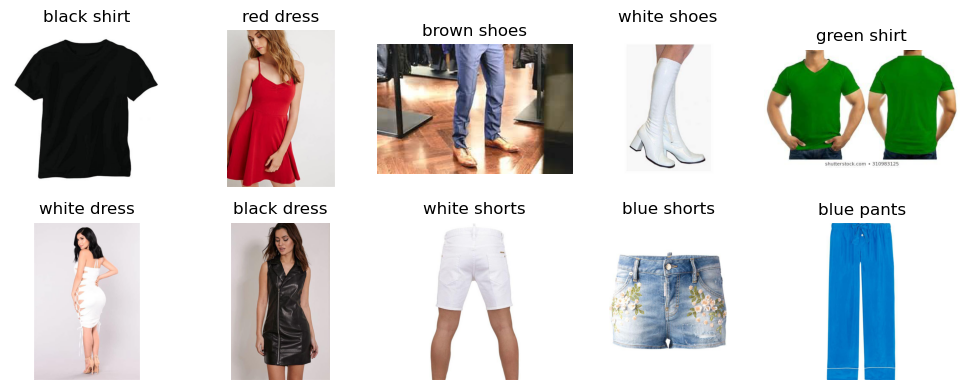

In [34]:
nrows, ncols = 2, 5
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))

for r in range(nrows):
    for c in range(ncols):
        sample = df.sample(n=1)
        img_path = sample.iloc[0,0]
        color = sample.iloc[0,1]
        apparel = sample.iloc[0,2]
        img = Image.open(img_path).convert('RGB')
        axs[r,c].imshow(img)
        axs[r,c].axis('off')
        axs[r,c].set_title(f'{color} {apparel}')
plt.tight_layout()
plt.show()

In [ ]:
train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.RandomCrop(224, padding=10),
    T.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_set = MultiLabelImageDataset(
    image_paths=train['img_path'].values,
    labels=train[['color', 'apparel']],
    transform=train_transforms,
    n_classes=18,
    device='cpu'
)
val_set = MultiLabelImageDataset(
    image_paths=val['img_path'].values,
    labels=val[['color', 'apparel']],
    transform=val_transforms,
    n_classes=18,
    device='cpu'
)

KeyError: 'labels'